# Import and Functions

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import json
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from matplotlib.patches import Patch

# Configure Matplotlib settings for font sizes
plt.rcParams.update({
    'font.size': 14,           # Global font size for the plot
    'axes.titlesize': 18,      # Font size for axis titles
    'axes.labelsize': 16,      # Font size for X and Y axis labels
    'xtick.labelsize': 14,     # Font size for X axis tick labels
    'ytick.labelsize': 14,     # Font size for Y axis tick labels
})


In [2]:

def format_label(label):
    """
    Format a label by capitalizing each word and replacing underscores with spaces.

    Parameters:
    label (str): The input label with underscores.

    Returns:
    str: The formatted label with each word capitalized and underscores replaced by spaces.
    """
    return ' '.join(word.capitalize() for word in label.split('_'))


def format_label_count(dca_id, count):
    """
    Format the label to include the count of events.

    Parameters:
    dca_id (str): The DCA_ID to be formatted.
    count (int): The count of events to be included in the label.

    Returns:
    str: The formatted label including the count of events in parentheses.
    """
    return f'{dca_id.replace("_", " ").title()} ({count})'


def parse_custom_colors(colors_json):
    """
    Parse a JSON string to extract custom color mappings.

    Parameters:
    colors_json (str): A JSON string containing color mappings where keys are color names
                       and values are color codes.

    Returns:
    dict: A dictionary containing color mappings extracted from the JSON string. 
          Returns an empty dictionary if the input JSON string is empty or None.
    """
    # Check if the JSON string is provided
    if colors_json:
        try:
            # Attempt to parse the JSON string into a Python dictionary
            custom_colors = json.loads(colors_json)
        except json.JSONDecodeError:
            # Handle JSON decoding errors (e.g., invalid JSON format)
            print("Error: Invalid JSON format.")
            custom_colors = {}
    else:
        # Default to an empty dictionary if the JSON string is empty or None
        custom_colors = {}

    return custom_colors



def load_data(path):
    """
    Load data from a CSV file into a GeoDataFrame.

    Parameters:
    path (str): The file path to the CSV file containing the data.

    Returns:
    GeoDataFrame: A GeoDataFrame with geometries and set CRS.
    """
    # Step 1: Read the CSV file into a DataFrame
    df = pd.read_csv(path)

    # Step 2: Convert the WKT geometries to Shapely geometries
    df['geometry'] = df['geometry'].apply(wkt.loads)

    # Step 3: Convert the DataFrame to a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry='geometry')

    # Rename the 'Unnamed: 0' column to 'ID_E'
    gdf = gdf.rename(columns={'Unnamed: 0': 'ID_E'})

    # Set the coordinate reference system (CRS) if it's not already set
    gdf.set_crs(epsg=4326, inplace=True)

    return gdf


def process_and_merge_disturbances(gdf, max_iterations=10):
    """
    Process and merge disturbance polygons based on spatial intersections and attributes.
    This function iteratively merges polygons that intersect and have matching attributes 
    until no more changes are detected or the maximum number of iterations is reached.

    Parameters:
    gdf (GeoDataFrame): The input GeoDataFrame containing disturbance polygons.
    region_8_shape_path (str): Path to the shapefile for the region (not used in this function but included for consistency).
    custom_colors (dict): Dictionary for custom colors in plotting (not used in this function but included for consistency).
    max_iterations (int): Maximum number of iterations for merging. The function will stop if merging does not change the data or if this number is reached.

    Returns:
    GeoDataFrame: A GeoDataFrame with merged disturbances and updated geometries.
    """
    print(f"  Initial number of records: {len(gdf)}")  

    # Step 1: Drop unnecessary columns that are not relevant for merging and filtering
    columns_to_drop = [
        'PERCENT_AFFECTED', 'HOST', 'HOST_CODE', 'DCA_CODE', 
        'DAMAGE_TYPE_CODE', 'DAMAGE_TYPE', 'cluster_id'
    ]
    gdf = gdf.drop(columns=columns_to_drop)
    print(f"  Number of records after dropping unnecessary columns: {len(gdf)}")  

    # Step 2: Ensure all geometries are valid
    # Fix invalid geometries by buffering them by zero distance
    gdf['geometry'] = gdf.geometry.apply(lambda geom: geom if geom.is_valid else geom.buffer(0))
    
    iteration = 0
    while iteration < max_iterations:
        print(f"> Iteration {iteration + 1}")

        # Step 3: Perform a spatial join to find intersecting polygons
        # This will find polygons that intersect with each other based on specific attributes
        spatial_intersections_att = gpd.sjoin(
            gdf, gdf, how="left", predicate="intersects", 
            lsuffix="left", rsuffix="right", 
            on_attribute=['DCA_ID', 'SURVEY_YEAR', 'REGION_ID', 'DA_Code_USDA']
        )
        print(f"  Number of intersected records: {len(spatial_intersections_att)}")

        # Step 4: Merge intersecting polygons based on 'ID_E_right' and then 'ID_E_left'
        merged_by_right = spatial_intersections_att.dissolve(by="ID_E_right", aggfunc="min")
        merged_by_left = merged_by_right.dissolve(by="ID_E_left", aggfunc="min")

        # Step 5: Reset index to bring 'ID_E_left' back as a column and drop unnecessary columns
        merged_data = merged_by_left.reset_index()
        merged_data = merged_data.drop(columns=['index_right'])
        
        # Step 6: Rename 'ID_E_left' to 'ID_E' and renumber the ID_E column
        merged_data = merged_data.rename(columns={'ID_E_left': 'ID_E'})
        merged_data['ID_E'] = range(len(merged_data))
        merged_data = merged_data.reset_index(drop=True)

        # Step 7: Check if merging has changed the data
        # If the number of records remains the same, stop the iterations
        if len(merged_data) == len(gdf):
            print(">> No more changes detected, stopping iterations.")
            break
        
        # Update the GeoDataFrame for the next iteration
        gdf = merged_data
        iteration += 1

    print(f"   Final number of merged records: {len(merged_data)}")

    return merged_data


def remove_overlapping_entries(df, year_column='SURVEY_YEAR', geometry_column='geometry', year_range=5):
    """
    Remove entries from a GeoDataFrame that overlap spatially within a specified temporal window.

    Parameters:
    df (GeoDataFrame): The input GeoDataFrame containing the data.
    year_column (str): The name of the column containing the survey year.
    geometry_column (str): The name of the column containing the geometry data.
    year_range (int): The number of years before and after the current year to check for overlaps.

    Returns:
    GeoDataFrame: A GeoDataFrame with overlapping entries removed.
    """
    # Create a copy of the GeoDataFrame to avoid modifying the original data
    df = df.copy()
    overlapping_indices = set()

    # Iterate over each row with a progress bar to check for spatial overlaps
    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc=f"Removing overlapping elements within ±{year_range} years"):
        current_year = row[year_column]
        current_geometry = row[geometry_column]

        # Define the time window for checking overlaps
        time_window = (df[year_column] >= (current_year - year_range)) & (df[year_column] <= (current_year + year_range))

        # Identify spatial overlaps within the defined time window
        spatial_overlaps = df.loc[time_window & df[geometry_column].intersects(current_geometry)]

        # If more than one entry overlaps, add their indices to the set of overlapping indices
        if len(spatial_overlaps) > 1:
            overlapping_indices.add(index)
            overlapping_indices.update(spatial_overlaps.index)

    # Drop the overlapping rows from the GeoDataFrame
    df_cleaned = df.drop(index=overlapping_indices)
    
    return df_cleaned

def keep_overlapping_entries(df, id_column='ID_E', year_column='SURVEY_YEAR', geometry_column='geometry', year_range=1):
    """
    Keep entries in a GeoDataFrame that overlap spatially within a ±`year_range` year temporal window.
    Adds a new column 'ID_O' containing the IDs of overlapping entries.

    Parameters:
    df (GeoDataFrame): The input GeoDataFrame containing the data.
    id_column (str): Name of the column containing unique IDs (e.g., 'ID_E').
    year_column (str): Name of the column containing the survey year.
    geometry_column (str): Name of the column containing geometry data.
    year_range (int): The number of years before and after the current year to check for overlaps.

    Returns:
    GeoDataFrame: A GeoDataFrame with overlapping entries and a new column 'ID_O' listing the IDs of overlapping elements.
    """
    df = df.copy()
    df['ID_O'] = None  # Initialize the 'ID_O' column to store overlapping IDs
    
    # Iterate over each row with a progress bar to check for spatial overlaps
    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc=f"Keeping overlaps within ±{year_range} years"):
        current_year = row[year_column]
        current_geom = row[geometry_column]
        current_id = row[id_column]
        
        # Define the time window for checking overlaps
        time_window = (df[year_column] >= (current_year - year_range)) & (df[year_column] <= (current_year + year_range))

        # Identify spatial overlaps within the time window
        spatial_overlaps = df.loc[time_window & df[geometry_column].intersects(current_geom)]

        # Exclude the current row from the overlaps
        spatial_overlaps = spatial_overlaps[spatial_overlaps[id_column] != current_id]

        # If overlaps are found, update the 'ID_O' column with overlapping IDs
        if not spatial_overlaps.empty:
            df.at[index, 'ID_O'] = spatial_overlaps[id_column].tolist()

    # Return only the rows where there is an overlap (i.e., 'ID_O' is not None)
    return df.dropna(subset=['ID_O'])

def analyze_overlaps(gdf_overlap, id_col='ID_E', year_col='SURVEY_YEAR', dca_id_col='DCA_ID'):
    """
    Analyze overlapping entries to determine the longest duration of overlap 
    and count the unique DCA_IDs associated with each entry.

    Parameters:
    gdf_overlap (GeoDataFrame): DataFrame containing overlapping entries.
    id_col (str): Column name for unique IDs (e.g., 'ID_E').
    year_col (str): Column name for the survey year.
    dca_id_col (str): Column name for the DCA_ID.

    Returns:
    GeoDataFrame: Updated DataFrame with columns for longest duration, DCA_ID count, and DCA_ID list.
    """
    # Initialize new columns for results
    gdf_overlap['Longest_Duration'] = None
    gdf_overlap['DCA_ID_Count'] = None
    gdf_overlap['DCA_ID_List'] = None

    # Analyze each entry with overlaps
    for idx, row in tqdm(gdf_overlap.iterrows(), total=gdf_overlap.shape[0], desc="Analyzing overlaps"):
        overlap_ids = row['ID_O']
        
        if overlap_ids:
            # Select rows with overlapping IDs
            overlap_data = gdf_overlap[gdf_overlap[id_col].isin(overlap_ids)]
            
            # Calculate longest duration (max year - min year)
            duration = overlap_data[year_col].max() - overlap_data[year_col].min() + 1
            
            # Get the unique DCA_IDs and their count
            dca_ids = overlap_data[dca_id_col].tolist()
            dca_id_count = len(dca_ids)
            
            # Update the current row with results
            gdf_overlap.at[idx, 'Longest_Duration'] = duration
            gdf_overlap.at[idx, 'DCA_ID_Count'] = dca_id_count
            gdf_overlap.at[idx, 'DCA_ID_List'] = dca_ids

    return gdf_overlap

def analyze_overlaps(gdf_overlap, id_col='ID_E', year_col='SURVEY_YEAR', dca_id_col='DCA_ID'):
    """
    Analyze overlapping entries to determine the longest duration of overlap 
    and count the unique DCA_IDs associated with each entry.

    Parameters:
    gdf_overlap (GeoDataFrame): DataFrame containing overlapping entries.
    id_col (str): Column name for unique IDs (e.g., 'ID_E').
    year_col (str): Column name for the survey year.
    dca_id_col (str): Column name for the DCA_ID.

    Returns:
    GeoDataFrame: Updated DataFrame with columns for longest duration, DCA_ID count, and DCA_ID list.
    """
    # Initialize new columns for results
    gdf_overlap['Longest_Duration'] = None
    gdf_overlap['DCA_ID_Count'] = None
    gdf_overlap['DCA_ID_List'] = None

    # Analyze each entry with overlaps
    for idx, row in tqdm(gdf_overlap.iterrows(), total=gdf_overlap.shape[0], desc="Analyzing overlaps"):
        overlap_ids = row['ID_O']
        
        if overlap_ids:
            # Select rows with overlapping IDs
            overlap_data = gdf_overlap[gdf_overlap[id_col].isin(overlap_ids)]
            
            # Calculate longest duration (max year - min year)
            duration = overlap_data[year_col].max() - overlap_data[year_col].min() + 1
            
            # Get the unique DCA_IDs and their count
            dca_ids = overlap_data[dca_id_col].tolist()
            dca_id_count = len(dca_ids)
            
            # Update the current row with results
            gdf_overlap.at[idx, 'Longest_Duration'] = duration
            gdf_overlap.at[idx, 'DCA_ID_Count'] = dca_id_count
            gdf_overlap.at[idx, 'DCA_ID_List'] = dca_ids

    return gdf_overlap


def analyze_and_enrich_overlaps(df, year_col='SURVEY_YEAR', id_col='ID_E', dca_col='DCA_ID'):
    """
    Explode the 'ID_O' column and enrich the DataFrame with 'O_Year', 'O_DCA_ID', and year differences.

    Parameters:
    df (GeoDataFrame): GeoDataFrame containing overlap information in 'ID_O'.
    id_col (str): Column name for unique IDs.
    year_col (str): Column name for the survey year.
    dca_col (str): Column name for DCA_ID.

    Returns:
    GeoDataFrame: Enriched DataFrame with 'O_Year', 'O_DCA_ID', and 'O_Y_diff'.
    """
    # Explode 'ID_O' into individual rows and drop unnecessary columns
    exploded_df = df.explode('ID_O').drop(columns=['Longest_Duration', 'DCA_ID_Count', 'DCA_ID_List'])

    # Create lookup dictionaries for years and DCA_IDs
    year_lookup = df.set_index(id_col)[year_col].to_dict()
    dca_lookup = df.set_index(id_col)[dca_col].to_dict()

    # Map 'ID_O' to 'O_Year' and 'O_DCA_ID' using lookup dictionaries
    exploded_df['O_Year'] = exploded_df['ID_O'].map(year_lookup)
    exploded_df['O_DCA_ID'] = exploded_df['ID_O'].map(dca_lookup)

    # Calculate year difference between 'O_Year' and current 'SURVEY_YEAR'
    exploded_df['O_Y_diff'] = exploded_df['O_Year'] - exploded_df[year_col]

    return exploded_df


def filter_disturbance_data(enriched_df, excluded_dca_types, start_year=2015, end_year=2020):
    """
    Filter disturbance data by year range, excluded DCA_ID types, and mismatches between DCA_ID and O_DCA_ID.
    
    Parameters:
    - enriched_df: DataFrame with enriched disturbance data.
    - excluded_dca_types: List of DCA_ID types to exclude.
    - start_year: Start of the year range.
    - end_year: End of the year range.

    Returns:
    - filtered_df_cleaned: DataFrame after all filters.
    - filtering_summary: Summary of the filtering process.
    """
    # Filter by year range
    df_filtered = enriched_df[(enriched_df['SURVEY_YEAR'] > start_year) & (enriched_df['SURVEY_YEAR'] <= end_year)].copy()
    
    # Exclude specified DCA_ID types
    initial_count = len(df_filtered)
    df_filtered = df_filtered[~df_filtered['DCA_ID'].isin(excluded_dca_types)]
    rows_dropped_dca = initial_count - len(df_filtered)
    
    # Find entries with mismatches between DCA_ID and O_DCA_ID, excluding NaNs
    mismatch_ids = df_filtered[
        (df_filtered['DCA_ID'] != df_filtered['O_DCA_ID']) &
        ~(df_filtered['DCA_ID'].isna() | df_filtered['O_DCA_ID'].isna())
    ]['ID_E'].unique()
    
    # Find entries with excluded O_DCA_ID types
    excluded_ids = df_filtered[df_filtered['O_DCA_ID'].isin(excluded_dca_types)]['ID_E'].unique()
    
    # Combine and exclude mismatched and excluded entries
    combined_exclusions = np.union1d(mismatch_ids, excluded_ids)
    df_cleaned = df_filtered[~df_filtered['ID_E'].isin(combined_exclusions)]
    rows_dropped_overlap = len(df_filtered) - len(df_cleaned)

    # Provide filtering summary
    total_events = len(df_cleaned)
    unique_events = df_cleaned['ID_E'].nunique()
    summary = (
        f"    Excluded {rows_dropped_dca} rows with specified DCA_ID types,"
        f"and {rows_dropped_overlap} additional rows due to mismatches or excluded O_DCA_ID.\n"
        f"    Unique events | Total events: {unique_events} | {total_events}\n"
        f"    Remaining overlapping events: {total_events - unique_events}"
    )
    
    return df_cleaned, summary


def calculate_area_in_km2(gdf):
    """
    Calculate the area of each polygon in the GeoDataFrame in square kilometers.

    Parameters:
    gdf (GeoDataFrame): GeoDataFrame with geometries in WKT format.

    Returns:
    GeoDataFrame: GeoDataFrame with an added column for area in square kilometers.
    """
    # Step 1: Set target CRS to EPSG:4326
    target_crs = 'EPSG:4326'
    gdf = gdf.to_crs(target_crs)
    
    # Step 2: Reproject to a CRS with meters (e.g., EPSG:3857)
    projected_gdf = gdf.to_crs('EPSG:3857')
    
    # Step 3: Calculate the area in square meters
    projected_gdf['area_m2'] = projected_gdf.geometry.area
    
    # Step 4: Convert the area to square kilometers
    projected_gdf['area_km2'] = projected_gdf['area_m2'] / 1e6
    
    # Step 5: Assign the calculated area to a new column in the original GeoDataFrame
    gdf['area_km2'] = projected_gdf['area_km2']
    
    # Step 6: Return the modified GeoDataFrame
    return gdf


In [29]:
def plot_regions_disturbances(disturbance_gdf, filepath, output_file, custom_colors, region_nr):

    usa = gpd.read_file(filepath)
    country = usa[usa.REGION == region_nr]
    
    region = country.explode()[0:1]  # Adjust this line as needed to select region 8
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

    # Create legend handles
    handles = []

    # Plot the boundaries of intersected geometries with custom colors
    for dca_id, color in custom_colors.items():
        subset = disturbance_gdf[disturbance_gdf['DCA_ID'] == dca_id]
        subset = subset[subset.is_valid]
         # Check if subset is not empty
        if not subset.empty:
            # Plot directly without using .boundary
            subset.plot(ax=ax, edgecolor=color, linewidth=0.5, linestyle='-', zorder=2)
            # Add handle for legend
            handles.append(Patch(color=color, label=format_label_count(dca_id, len(subset))))

    # Plot the boundary of the selected region
    region.boundary.plot(ax=ax, color='black', linewidth=0.5, linestyle='--', zorder=3) 
    # Add handle for region boundary with dotted border
     # Add handle for region boundary with transparent box and red dotted border
    handles.append(Patch(facecolor='none', edgecolor='black', linestyle='--', linewidth=1, 
                          label=f'Region {region_nr} Boundary',))


    # Customize the plot appearance
    ax.set_title(f'IDS Disturbances within Region {region_nr}', fontsize=18, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

    # Set the aspect ratio of the plot to be equal
    ax.set_aspect('equal')

    # Add the legend with all handles
    ax.legend(handles=handles, loc='best', fontsize=14)

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')  
    plt.show()


# Main and Testing

In [30]:
"""
Main function to set up the environment, load file paths, and get custom color mappings and calls functions
"""

print("Set up environment variables ...")
# Load environment variables from a .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

os.environ['REGION'] = '1'  # Set it directly in Python for testing
region = os.getenv('REGION')
print(f"Working on USDA Region {region} ...")
region_id=str(region).zfill(2)
# Define file paths using environment variables
region_shape_path = f"{os.getenv('REGION_SHAPE')}S_USA.AdministrativeRegion.shp"
ids_region_file_path = f"{os.getenv('IDS_REGIONS')}CONUS_Region{region}_dissolved.csv"
file_output_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
figure_output_path = f"{os.getenv('FIGURES')}/p1_f1_disturbances_region_{region_id}.png"

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)


Set up environment variables ...
Working on USDA Region 1 ...


In [ ]:
print(f"Step 1: Loading CSV file for Region {region_id}...") 
gdf = load_data(ids_region_file_path)

print("Step 2: Processing and cleaning disturbance data...")
merged_gdf = process_and_merge_disturbances(gdf)

print("Step 3: Removing temporal and spatial overlaps...")
gdf_no_overlap = remove_overlapping_entries(merged_gdf, year_range=5)
print(f"> Number of records after removing overlaps: {len(gdf_no_overlap)}")

print("Step 4: Identifying entries with temporal and spatial overlaps within ±1 year...")
gdf_overlap = keep_overlapping_entries(merged_gdf, year_range=1)
print(f"> Number of records with detected overlaps: {len(gdf_overlap)}")

# Step 5: Analyzing overlaps
print("Step 5: Analyzing overlaps...")
gdf_overlap_analyzed = analyze_overlaps(gdf_overlap)

# Step 6: Merging datasets with and without overlaps
print("Step 6: Merging datasets...")
merged_gdf = gpd.GeoDataFrame(pd.concat([gdf_no_overlap, gdf_overlap_analyzed], ignore_index=True))

# Step 7: Exploding geometries and enriching data with DCA and year information
print("Step 7: Exploding geometries and enriching data...")
enriched_df = analyze_and_enrich_overlaps(merged_gdf)

# Step 8: Filter disturbance data
print("Step 8: Filtering disturbances between 2016 and 2020...")
excluded_dca_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
filtered_df_cleaned, filtering_summary = filter_disturbance_data(enriched_df, excluded_dca_types)
print(filtering_summary)

# Step 9: Generate new index_usda values
print("Step 9: Generating new index_usda values...")
filtered_df_cleaned['IDX_D'] = filtered_df_cleaned.apply(
    lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1
)

# Step 10: Calculate area in km²
print("Step 10: Calculating area in km²...")
gdf_with_area = calculate_area_in_km2(filtered_df_cleaned)

# Step 11: Remove elements larger than 15 km²
print("Step 11: Removing elements larger than 15 km²...")
gdf_area = gdf_with_area[gdf_with_area['area_km2'] <= 15]

# Output summary
total_elements = len(gdf_area)
unique_events = len(gdf_area['ID_E'].unique())
overlapping_events = total_elements - unique_events

print(f"Number of elements after removing large areas: {total_elements}")
print(f"    Unique events | Total events: {unique_events} | {total_elements}")
print(f"    Remaining overlapping events: {overlapping_events}")

# Rename columns to avoid issues with field name normalization
print("Renaming columns...")
column_renames = {
    'SURVEY_YEAR': 'SURVEY_Y',
    'DA_Code_USDA': 'DA_C_USDA'
}
data = gdf_area.rename(columns=column_renames)


# Step 12: Plot the final results
print("Step 12: Plotting the final results...")
plot_regions_disturbances(
    data, 
    region_shape_path, 
    output_file= figure_output_path, 
    custom_colors=custom_colors,
    region_nr= region_id
)

# Step 13: Save the final GeoDataFrame to a shapefile
print(f"Step 13: Saving results to: {file_output_path} ...")
data.to_file(file_output_path, index=False)
print(f"Results successfully saved to: {file_output_path}")


In [31]:
region_01 = gpd.read_file('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//region01_dca_filtered_ids_usda_polygons.shp')

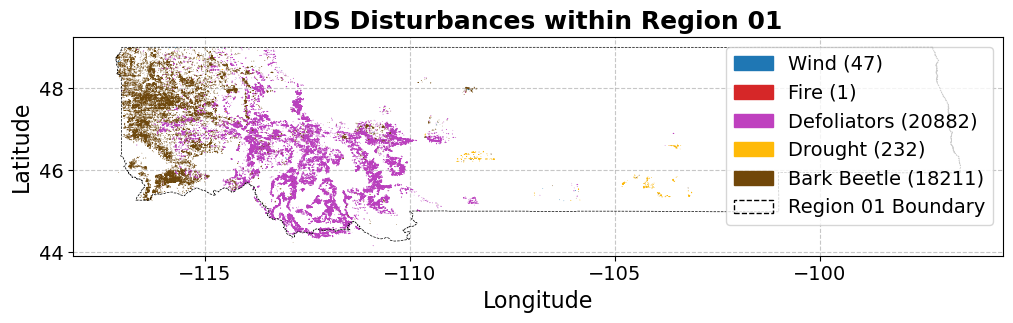

In [32]:
plot_regions_disturbances(
    region_01, 
    region_shape_path, 
    output_file= figure_output_path, 
    custom_colors=custom_colors,
    region_nr= region_id
)

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

def get_region_shape_bounds(filepath, region_nr, output_path):
    # Load the shapefile
    usa = gpd.read_file(filepath)
    
    # Filter for the specified region
    country = usa[usa['REGION'] == region_nr]
    
    # Explode multipolygons (if any) and get the first part
    region = country.explode(index_parts=False)[0:1]
    
    # Get the bounding box of the region
    bounds = region.total_bounds  # Returns (x_min, y_min, x_max, y_max)
    
    # Extract values from the bounding box
    x_min, y_min, x_max, y_max = bounds
    
    # Plot the region shape
    fig, ax = plt.subplots(figsize=(8, 8))
    region.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=1)
    
    # Plot the bounding box as a rectangle
    bbox = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                         edgecolor='brown', facecolor='none', linewidth=2, linestyle='--')
    ax.add_patch(bbox)
    
    # Plot the bounding box corners with red dots
    ax.scatter([x_min, x_max, x_min, x_max], [y_min, y_min, y_max, y_max], color='red', zorder=5)
    
    # Set axis labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Region {region_nr} with Bounding Box')
    
    # Save the figure to the specified output path
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)  # Close the figure to free memory
    
    # Return the bounding box coordinates
    return x_min, y_min, x_max, y_max


Working on USDA Region 9 ...


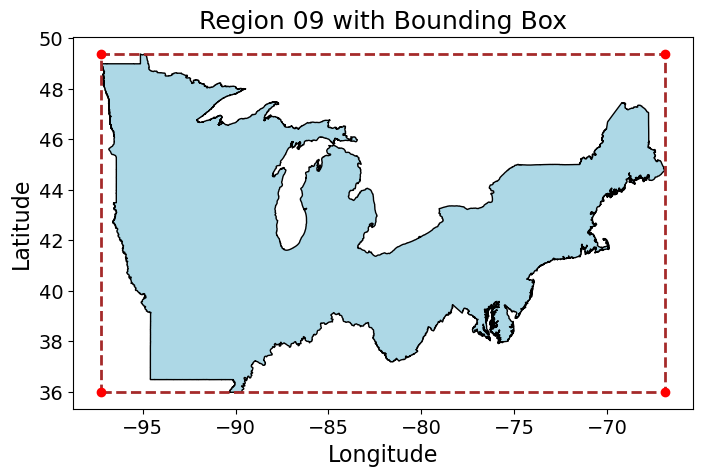

(-97.23919599999999, 35.995682999999985, -66.8861698, 49.38435800000002)

In [19]:
r = os.getenv('REGION')
print(f"Working on USDA Region {region} ...")
r_id=str(r).zfill(2)
# Define file paths using environment variables
region_shape_path = f"{os.getenv('REGION_SHAPE')}S_USA.AdministrativeRegion.shp"

get_region_shape_bounds(region_shape_path, r_id)